<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/01_Frutas_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio A

## Clasificación binaria desde cero con NumPy

**Objetivo:** implementar una neurona para diferenciar manzanas y bananos usando Sigmoide, Binary Cross Entropy y backpropagation.

### Conceptos que veremos
- Aprendizaje supervisado
- Clasificación binaria
- Forward propagation
- Sigmoide
- Loss
- Backpropagation
- Learning rate
- Accuracy

In [14]:

# ============================================
# 1. LIBRERÍAS
# ============================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [15]:

# ============================================
# 2. DATASET DE FRUTAS: MANZANA VS BANANO
# ============================================
# Cada fila representa una fruta.
# Características:
#   - peso (gramos)
#   - longitud (cm)
#   - nivel de amarillo (0 a 1)
#
# Etiquetas:
#   0 = MANZANA
#   1 = BANANO

X = np.array([
    # MANZANAS
    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS
    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]
], dtype=float)

y = np.array([0] * 10 + [1] * 10).reshape(-1, 1)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (20, 3)
Forma de y: (20, 1)


In [16]:

# ============================================
# 3. SEPARAR ENTRENAMIENTO Y PRUEBA
# ============================================
# 80% de los datos se utilizan para aprender y 20% para comprobar
# si la red generaliza a ejemplos que no utilizó durante el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (16, 3)
X_test : (4, 3)
y_train: (16, 1)
y_test : (4, 1)


In [17]:
# ============================================
# 4. NORMALIZAR / ESTANDARIZAR
# ============================================
# Las tres características tienen escalas diferentes.
# StandardScaler transforma los datos para que trabajen en escalas comparables.

scaler = StandardScaler()

# IMPORTANTE:
# fit_transform SOLO se aplica al conjunto de entrenamiento.
# El conjunto de prueba se transforma con el mismo scaler.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos escalados correctamente.")
print("Primeras 5 filas escaladas:")
print(X_train[:5])

Datos escalados correctamente.
Primeras 5 filas escaladas:
[[ 1.10782916 -0.94158485 -0.93420715]
 [ 1.26848113 -0.95920515 -0.93420715]
 [-1.14129832  0.78520467  0.88863607]
 [-1.24839963  0.87330618  0.88863607]
 [-0.87354505  0.96140768  1.01015895]]


In [18]:

# ============================================
# 5. FUNCIÓN DE ACTIVACIÓN: SIGMOIDE
# ============================================
# La sigmoide transforma cualquier valor a un rango entre 0 y 1.
# En clasificación binaria la interpretamos como una probabilidad.

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ============================================
# 6. FUNCIÓN DE PÉRDIDA: BINARY CROSS ENTROPY
# ============================================
# Un loss pequeño significa que las predicciones están más cerca
# de las etiquetas reales.

def calcular_error(y_real, y_predicha):
    epsilon = 1e-8
    return -np.mean(
        y_real * np.log(y_predicha + epsilon)
        + (1 - y_real) * np.log(1 - y_predicha + epsilon)
    )


In [19]:

# ============================================
# LABORATORIO A - UNA NEURONA DESDE CERO
# ============================================
# Arquitectura:
# 3 entradas -> 1 neurona de salida
#
# Esta neurona aprenderá a distinguir:
# 0 = manzana
# 1 = banano

np.random.seed(42)

W = np.random.randn(3, 1) * 0.01
b = 0.0

# ---------------------------
# Primera predicción
# ---------------------------
Z = X_train @ W + b
A = sigmoid(Z)

print("Pesos iniciales:")
print(W)
print("\nPrimeras predicciones:")
print(A[:5])
print("\nError inicial:", calcular_error(y_train, A))


Pesos iniciales:
[[ 0.00496714]
 [-0.00138264]
 [ 0.00647689]]

Primeras predicciones:
[[0.50018847]
 [0.50039405]
 [0.49975024]
 [0.49958679]
 [0.50021859]]

Error inicial: 0.6929322941038263


In [20]:
# ---------------------------
# Una actualización manual (backpropagation)
# ---------------------------
# dZ, dW y db son gradientes.
# Indican en qué dirección deben modificarse los parámetros
# para reducir el error.

dZ = A - y_train
dW = X_train.T @ dZ / len(X_train)
db = np.mean(dZ)

learning_rate = 0.1

W = W - learning_rate * dW
b = b - learning_rate * db

print("\nPesos después de una actualización:")
print(W)
print("Bias actualizado:", b)


Pesos después de una actualización:
[[-0.04173251]
 [ 0.0483245 ]
 [ 0.05620925]]
Bias actualizado: -2.4020049838036074e-12


In [21]:

# ============================================
# 7. ENTRENAMIENTO COMPLETO: 2000 ÉPOCAS
# ============================================
np.random.seed(42)

W = np.random.randn(3, 1) * 0.01
b = 0.0

learning_rate = 0.1
epochs = 2000

loss_history = []

for epoch in range(epochs):

    # 1. FORWARD PROPAGATION
    Z = X_train @ W + b
    A = sigmoid(Z)

    # 2. LOSS
    error = calcular_error(y_train, A)
    loss_history.append(error)

    # 3. BACKPROPAGATION
    dZ = A - y_train
    dW = X_train.T @ dZ / len(X_train)
    db = np.mean(dZ)

    # 4. ACTUALIZACIÓN DE PESOS
    W = W - learning_rate * dW
    b = b - learning_rate * db

    if epoch % 400 == 0:
        print(f"Época: {epoch:4d} | Error: {error:.4f}")

Época:    0 | Error: 0.6929
Época:  400 | Error: 0.0093
Época:  800 | Error: 0.0046
Época: 1200 | Error: 0.0031
Época: 1600 | Error: 0.0023


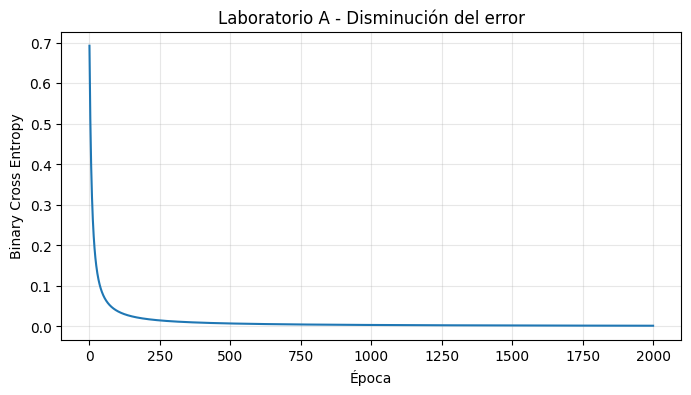

In [22]:
# ---------------------------
# Gráfica del aprendizaje
# ---------------------------
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Laboratorio A - Disminución del error")
plt.xlabel("Época")
plt.ylabel("Binary Cross Entropy")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# ---------------------------
# Evaluación con datos de prueba
# ---------------------------
probabilidades = sigmoid(X_test @ W + b)
predicciones = (probabilidades >= 0.5).astype(int)
accuracy = np.mean(predicciones == y_test)

print("\nProbabilidades:")
print(probabilidades)

print("\nPredicciones:")
print(predicciones)

print("\nValores reales:")
print(y_test)

print(f"\nAccuracy en prueba: {accuracy:.4f}")


Probabilidades:
[[5.57638046e-03]
 [8.91035971e-04]
 [9.97758298e-01]
 [9.97877530e-01]]

Predicciones:
[[0]
 [0]
 [1]
 [1]]

Valores reales:
[[0]
 [0]
 [1]
 [1]]

Accuracy en prueba: 1.0000


In [24]:
# ---------------------------
# Fruta nueva
# ---------------------------
fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

probabilidad_nueva = sigmoid(fruta_nueva_escalada @ W + b)
resultado = "BANANO" if probabilidad_nueva[0, 0] >= 0.5 else "MANZANA"

print("\nFruta nueva:", fruta_nueva[0])
print("Probabilidad de banano:", float(probabilidad_nueva[0, 0]))
print("Clasificación:", resultado)


Fruta nueva: [124.    19.     0.94]
Probabilidad de banano: 0.9980514829516615
Clasificación: BANANO


### Interpretación esperada
El loss debe disminuir durante el entrenamiento. Después se evalúan las 4 frutas reservadas para prueba y se calcula el accuracy. La guía documenta un accuracy de 1.0 para este pequeño conjunto sintético; el resultado concreto puede depender del entorno y la ejecución.